# Confidence interval asymmetric
## Do some tests with asymmetric uncertainties and confidence intervals

### Write a function that does everything

In [1]:
std::pair<std::vector<double>, std::vector<double> > ScanAsymmetricCL(
    double Value, double MinusErr, double PlusErr
) {
    // Get the asymmetric Gaussian function boundaries
    const double xMin =
        (MinusErr < PlusErr) ? (Value - PlusErr*MinusErr/(PlusErr - MinusErr)) : (Value - 7.0*MinusErr);
    const double xMax =
        (MinusErr < PlusErr) ? (Value + 7.0*PlusErr) : (Value + PlusErr*MinusErr/(MinusErr - PlusErr));
    // The asymmetric Gaussian
    auto AsymmetricGauss = [] (double *x, double *p) {
        // x[0]: Function value
        // p[0]: Central value
        // p[1]: Negative uncertainty
        // p[2]: Positive uncertainty
        const double Std2 = p[1]*p[2];
        const double StdDiff = p[1] - p[2];
        const double xDiff = p[0] - x[0];
        const double Var = Std2 + StdDiff*xDiff;
        return TMath::Exp(-(xDiff*xDiff)/(2.0*Var));
    };
    // Create the ROOT TF1 function so that we can integrate
    const std::array<double, 3> Params{Value, MinusErr, PlusErr};
    TF1 f1("f1", AsymmetricGauss, xMin, xMax, 3);
    f1.SetParameters(Params.data());
    // Total integral for normalisation
    const double TotalIntegral = f1.Integral(xMin, xMax);
    // Function for getting the bounds for a given function value
    auto GetBounds = [&] (double x) {
        double Lower = f1.GetX(x, xMin, Value);
        double Upper = f1.GetX(x, Value, xMax);
    return std::make_pair(Lower, Upper);
    };
    // Get the confidence level at a given function value
    auto GetCLIntegral = [&] (double x) {
        std::pair<double, double> Bounds = GetBounds(x);
        return 1.0 - f1.Integral(Bounds.first, Bounds.second)/TotalIntegral;
    };
    // Make a list of points
    std::vector<double> x_left, x_right, y_left, y_right;
    for(double i = 0.01; i < 1.0; i += 0.01) {
        std::pair<double, double> Bounds = GetBounds(i);
        x_left.push_back(Bounds.first);
        x_right.push_back(Bounds.second);
        y_left.push_back(GetCLIntegral(i));
        y_right.push_back(y_left.back());
    }
    x_right.push_back(Value);
    y_right.push_back(1.0);
    std::reverse(x_right.begin(), x_right.end());
    std::reverse(y_right.begin(), y_right.end());
    std::vector<double> x = x_left;
    std::vector<double> y = y_left;
    x.insert(x.end(), x_right.begin(), x_right.end());
    y.insert(y.end(), y_right.begin(), y_right.end());
    // Return lists
    return std::make_pair(x, y);
}

### Test function

In [2]:
auto Points = ScanAsymmetricCL(-0.40, 0.17639751872586284520, 0.47286571272863031634);

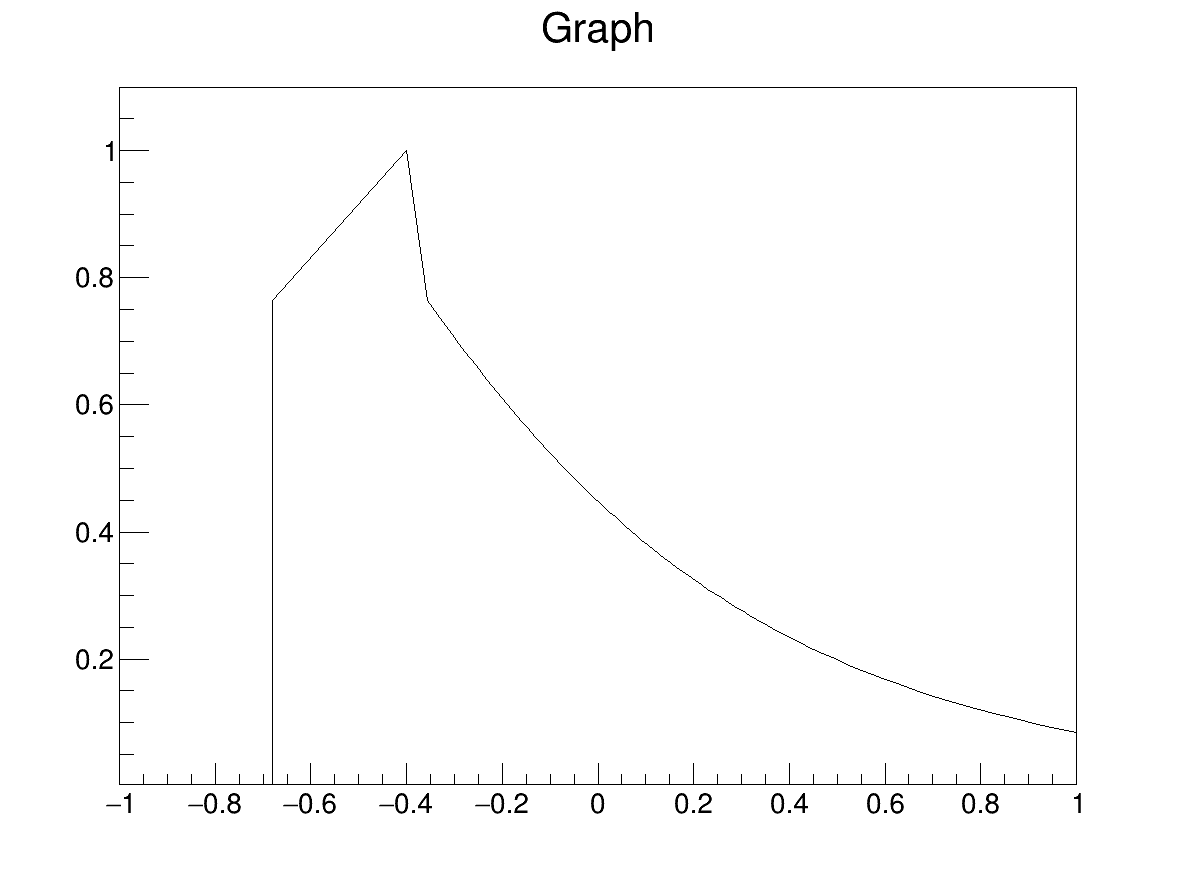

In [3]:
TGraph Graph(Points.first.size(), Points.first.data(), Points.second.data());
Graph.GetXaxis()->SetLimits(-1.0, 1.0);
TCanvas c("c", "", 1200, 900);
Graph.Draw("ALP");
c.Draw();

In [4]:
Points.first

(std::vector<double, std::allocator<double> > &) { -0.68135341, -0.68135341, -0.68135341, -0.68135341, -0.68135341, -0.68135341, -0.68135341, -0.68135341, -0.68135341, -0.68135341, -0.68135341, -0.68135341, -0.68135341, -0.68135341, -0.68135341, -0.68135341, -0.68135341, -0.68135341, -0.68135341, -0.68135341, -0.68135341, -0.68135341, -0.68135341, -0.68135341, -0.68135341, -0.68135341, -0.68135341, -0.68135341, -0.68135341, -0.68135341, -0.68135341, -0.68135341, -0.68135341, -0.68135341, -0.68135341, -0.68135341, -0.68135341, -0.68135341, -0.68135341, -0.68135341, -0.68135341, -0.68135341, -0.68135341, -0.68135341, -0.68135341, -0.68135341, -0.68135341, -0.68135341, -0.68135341, -0.68135341, -0.68135341, -0.68135341, -0.68135341, -0.68135341, -0.68135341, -0.68135341, -0.68135341, -0.68135341, -0.68135341, -0.68135341, -0.68135341, -0.68135341, -0.68135341, -0.68135341, -0.68135341, -0.68135341, -0.68135341, -0.68135341, -0.68135341, -0.68135341, -0.68135341, -0.68135341, -0.68135341, 

In [5]:
Points.second

(std::vector<double, std::allocator<double> > &) { 0.0026174027, 0.0089020086, 0.015199746, 0.021508879, 0.027828533, 0.034158200, 0.040497566, 0.046846438, 0.053204706, 0.059572315, 0.065949253, 0.072335544, 0.078731239, 0.085136412, 0.091551156, 0.097975584, 0.10440982, 0.11085401, 0.11730831, 0.12377289, 0.13024793, 0.13673363, 0.14323018, 0.14973782, 0.15625676, 0.16278726, 0.16932956, 0.17588395, 0.18245068, 0.18903007, 0.19562242, 0.20222805, 0.20884730, 0.21548051, 0.22212807, 0.22879036, 0.23546777, 0.24216073, 0.24886969, 0.25559511, 0.26233746, 0.26909726, 0.27587505, 0.28267136, 0.28948680, 0.29632198, 0.30317753, 0.31005415, 0.31695254, 0.32387345, 0.33081768, 0.33778606, 0.34477947, 0.35179884, 0.35884517, 0.36591948, 0.37302290, 0.38015659, 0.38732180, 0.39451987, 0.40175220, 0.40902030, 0.41632580, 0.42367042, 0.43105601, 0.43848458, 0.44595826, 0.45347937, 0.46105042, 0.46867412, 0.47635341, 0.48409152, 0.49189196, 0.49975856, 0.50769556, 0.51570763, 0.52379994, 0.53197